# Solutions for Chapter 5 and 6 Assigned Problems

In [7]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

## Homework 3 Spring 2026
- 5.4.3
  - **Note:** "Explain" means no code is necessary. You can use words, pictures, and/or pseudocode to show me that you understand how this procedure works.
- 5.4.5: The `Default` data set is on [the DataSets page](../DataSets/DataSets.md)
  <!-- - **Note:** Here they use "validation set" for what I usually call "testing set". -->
  - **Hint:** For part (c), you do not need to regenerate the data. You have the same data set, but you are generating a new split of the data. This could be as easy as setting a new seed.
- 5.4.8 (a-e)
  - *Added part f:* Repeat part (c) using $k$-fold CV for $k=5,10,15,20$. Plot your results for error vs. degree for all these plus the LOOCV version. What do you notice?
  - <span style="color: violet"> You don't need to plot this for the training error, it's annoyingly difficult to get that out of the easy-mode version of $k$-fold CV. Just do it for test error. If you really want to try to get the training error plotted, too, take a look [here](https://scikit-learn.org/stable/modules/cross_validation.html#the-cross-validate-function-and-multiple-metric-evaluation).</span>

- 6:
  - Forward and backward selection

Below are the training and testing error from doing linear regression on different subsets of the variables from the `auto` data set to predict `mpg`.

| Variables                                    | Train Score | Test Score |
|----------------------------------------------|-------------|------------|
| null model                                   | 60.76       | 60.73      |
| (cylinders,)                                 | 24.02       | 24.15      |
| (horsepower,)                                | 23.94       | 24.19      |
| (weight,)                                    | 18.68       | 18.84      |
| (acceleration,)                              | 49.87       | 50.26      |
| (cylinders, horsepower)                      | 20.85       | 21.13      |
| (cylinders, weight)                          | 18.38       | 18.55      |
| (cylinders, acceleration)                    | 23.94       | 24.38      |
| (horsepower, weight)                         | 17.84       | 18.03      |
| (horsepower, acceleration)                   | 22.46       | 22.70      |
| (weight, acceleration)                       | 18.25       | 18.61      |
| (cylinders, horsepower, weight)              | 17.76       | 17.99      |
| (cylinders, horsepower, acceleration)        | 20.06       | 20.44      |
| (cylinders, weight, acceleration)            | 18.13       | 18.54      |
| (horsepower, weight, acceleration)           | 17.84       | 18.16      |
| (cylinders, horsepower, weight, acceleration)| 17.76       | 18.13      |


- (Parts a, b, and c) For each of the three subset selection methods discussed in class ((a) best subset selection, (b) forward selection, and (c) backward selection), do the following 
  - Describe the steps taken in the algorithm to arrive at a conclusion for the best possible model. 
  - Be sure to say what $M_k$ is for $k= 0 , 1, \cdots, 4$. 
  - What is the best model returned by the algorithm? 
  - How many models do you have to train to arrive at the conclusion? 
- (d) Are your answers to (a), (b), and (c) the same? Do we expect them to be? 

*Note that we am not assuming you need to code any of these options, you only need to calculate by hand.*

### Grading distribution 

- 5.4.3 (13 points)
- 5.4.5 (36 points)
- 5.4.8 (43 points)
- 6 (8 points)

## 5.4.3
We now review k-fold cross-validation.

- (a) (5 points): Explain how k-fold cross-validation is implemented.


###ANSWER### k-fold cross-validation works by splitting the dataset into k equal parts, then training the model k times. Each time, you use k−1 folds for training and 1 fold for validation, rotating the validation fold each run. Finally, you average the k validation scores to estimate performance.

## 5.4.3
- (b)(8 points): What are the advantages and disadvantages of k-fold cross validation relative to:
    - i. The validation set approach?
    - ii. LOOCV?

###ANSWER###
- Advantage/disadvantage:
  - Vs validation set, its better approximation of test error, less variation. (4 points)
  - Vs LOOCV it's better computation time (4 points)

## 5.4.5

In Chapter 4, we used logistic regression to predict the probability of default using income and balance on the Default data set. We will now estimate the test error of this logistic regression model using the validation set approach. Do not forget to set a random seed before beginning your analysis.

(a) (8 points) Fit a logistic regression model that uses income and balance to predict default.


In [8]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split

In [9]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/0bf0b0b65f603971cd33a04ad934449c/Default.csv"
Default = pd.read_csv(url)
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [12]:
###ANSWER###
X = Default[['income', 'balance']] #2 points)
y = Default['default']# 2 points
clf = LogisticRegression(random_state=0) #2 points
clf.fit(X,y) #2 points

print(clf.coef_) #1 points
print(clf.intercept_) # 1points

[[2.08091985e-05 5.64710797e-03]]
[-11.54047812]



(b)(11 points): Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:

- i. Split the sample set into a training set and a validation set.
- ii. Fit a multiple logistic regression model using only the training observations.
- iii. Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.
- iv. Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.


- i (2 points). Split the sample set into a training set and a validation set.

In [14]:
###ANSWER### 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0) #2 points

- ii (4 points). Fit a multiple logistic regression model using only the training observations.

In [44]:
###ANSWER###
clf = LogisticRegression(random_state=0) # 2 points
clf.fit(X_train, y_train) # 2 points

LogisticRegression(random_state=0)

- iii (3 points). Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.
- iv (2 points). Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.

In [46]:
###ANSWER###

clf.score(X_test, y_test) # 2 points
print(f"The accuracy of the model is {100*clf.score(X_test, y_test):.2f}%") # 1 points
print(f"The error of the model is {100*(1-clf.score(X_test, y_test)):.2f}%") # 2 points

The accuracy of the model is 96.40%
The error of the model is 3.60%



(c) (4 points): Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained. 


In [18]:
##ANSWER###
# They should notice something about the spread of the results. NO big difference # 2 points
for i in range(3): # 2 points
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    clf = LogisticRegression()
    clf.fit(X_train, y_train)

    clf.score(X_test, y_test)
    print(f"The error of the model is {100*(1-clf.score(X_test, y_test)):.2f}%")

The error of the model is 2.90%
The error of the model is 3.20%
The error of the model is 2.63%



(d) (13 points): Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a dummy variable for student leads to a reduction in the test error rate.

In [1]:
###ANSWER###

X = pd.get_dummies(Default.drop('default', axis=1), drop_first=True) #1 points
y = Default['default'] # 1 points

Scores = [] # 1 points
for i in range(100): # 2 points
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    clf = LogisticRegression()
    clf.fit(X_train, y_train)

    Scores.append(1-clf.score(X_test, y_test)) # 1 points
    # print(f"The error of the model is {100*(1-clf.score(X_test, y_test)):.2f}%")

plt.hist(Scores) # 2 points
print(np.average(Scores)) # 1 points
# Not a huge change from before # 1 points

NameError: name 'pd' is not defined

#### ✅ Question (d): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (d) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).


In [ ]:
###YOUR ANSWER HERE###

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.


In [53]:
### YOUR ANSWER HERE##
#YOUR PROMPTS##

##AI OUTPUTS##

## 5.4.8 (a-e, added part f)

We will now perform cross-validation on a simulated data set.

(a)(3 points): Generate a simulated data set as follows:

```{python}
rng = np.random.default_rng(1) 
x = rng.normal(size=100) 
y = x - 2 * x**2 + rng.normal(size=100)
```

In this data set, what is n and what is p? Write out the model used to generate the data in equation form.


In [47]:
rng = np.random.default_rng(1) 
x = rng.normal(size=100) 
y = x - 2 * x**2 + rng.normal(size=100)


###ANSWER###
- $n$ is the number of data points, so this one is 100 # (1 points)
- $p$ is the number of variables, so here it's 1. # (1 points)
- The model used to generate the data is $Y = X-2X^2 + \varepsilon$. # (1 points)


(b) (3 points): Create a scatterplot of X against Y . Comment on what you find.


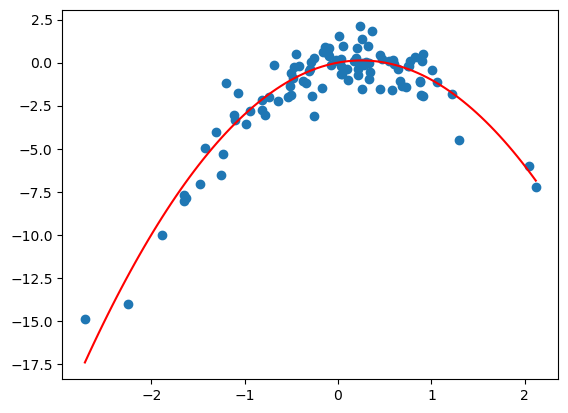

In [22]:
###ANSWER###
# Not sure what comments to go for, but maybe something about it being non-linear is reasonable. ( 1 point)
# The red line isn't required, just my plotting
plt.scatter(x,y) # 2 points
t= np.linspace(x.min(),x.max(),100)
f = t-2*t**2
plt.plot(t,f, color='red')


(c)(13 points): Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

- $Y = \beta_0 + \beta_1 X + \varepsilon$ 
- $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon$
- $Y = \beta_0 + \beta_1 X+ \beta_2 X^2+ \beta_3 X^3 + \varepsilon$
- $Y = \beta_0 + \beta_1 X+ \beta_2 X^2+ \beta_3 X^3+ \beta_4 X^4 + \varepsilon$

Note you may find it helpful to use the data.frame() function to create a single data set containing both X and Y .


In [48]:
from sklearn.preprocessing import PolynomialFeatures

d = 4

X_poly = PolynomialFeatures(degree=d, include_bias=False).fit_transform(x[:,None])

X = pd.DataFrame(X_poly, columns=[f'x^{i}' for i in range(1,d+1)])

y = pd.Series(y)


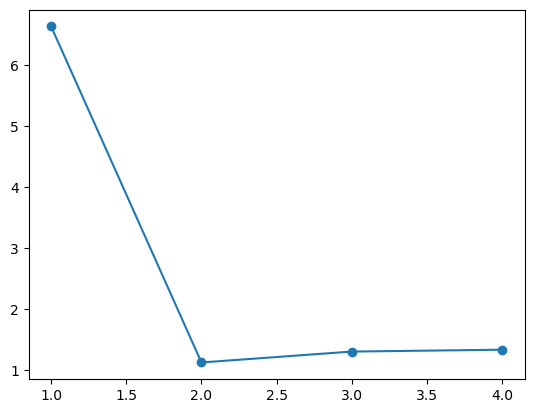

In [49]:
###ANSWER###
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

Score_List = [] # 1 point


for d in range(1,5): # 2 points
    X_poly = PolynomialFeatures(degree=d, include_bias=False).fit_transform(x[:,None]) # 1 point

    X = pd.DataFrame(X_poly, columns=[f'x^{i}' for i in range(1,d+1)])

    y = pd.Series(y)

    #build linear regression model
    model = LinearRegression() # 1 point

    #use LOO CV to evaluate model
    scores = cross_val_score(model, X, y, 
                            scoring='neg_mean_squared_error',
                            cv=loo) # 2 points

    #view mean absolute error
    Score_List.append(np.average(np.absolute(scores))) # 1 point

plt.plot(range(1,5), Score_List,marker = 'o') # 2 points

#### ✅ Question (c): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (c) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

###YOUR ANSWER HERE##

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.


In [ ]:
### YOUR ANSWER HERE##
#YOUR PROMPTS##

##AI OUTPUTS##



(d) (4 points): Repeat (c) using another random seed, and report your results.

Are your results the same as what you got in (c)? Why?


In [ ]:
##YOUR CODE HERE##

###ANSWER### 
*The LOOCV errors are the same because LOOCV does not involve random splitting. Each observation is left out exactly once, so changing the random seed does not change the training/validation sets.* ( 4 points)


(e) (4 points): Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.


###ANSWER###
*Lowest value is at degree 2 (2 points), which makes sense since the data was generated with a degree 2 polynomial (2 points).*

*Added part f (16 points):* Repeat part (c) using $k$-fold CV for $k=5,10,15,20$. Plot your results for error vs. degree for all these plus the LOOCV version. What do you notice?


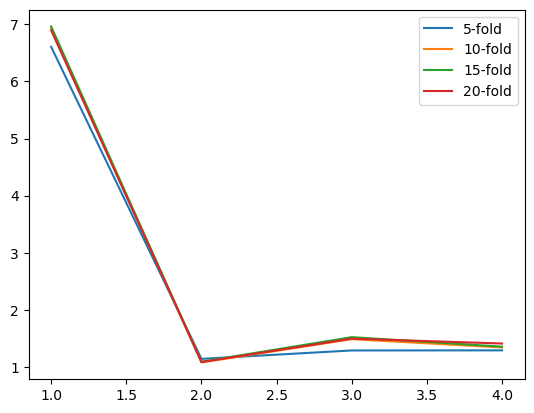

In [35]:
###ANSWER###
All_Score_Lists = [] # 1 point
for k in [5, 10, 15, 20]: # 2 points

    Score_List = []


    for d in range(1,5): # 2 points
        X_poly = PolynomialFeatures(degree=d, include_bias=False).fit_transform(x[:,None])

        X = pd.DataFrame(X_poly, columns=[f'x^{i}' for i in range(1,d+1)])

        y = pd.Series(y)

        #build linear regression model
        model = LinearRegression()

        #use k-fold CV to evaluate model
        scores = cross_val_score(model, X, y, 
                                scoring='neg_mean_squared_error',
                                cv=k) # 2 points

        #view mean absolute error
        Score_List.append(np.average(np.absolute(scores))) # 1 point

    plt.plot(range(1,5), Score_List, label = f'{k}-fold') # 2 points

plt.legend()# 1 point

####The results are pretty darn similar. ### 2 points

#### ✅ Question (f): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (f) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

###YOUR ANSWER HERE##

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.

In [54]:
### YOUR ANSWER HERE##
#YOUR PROMPTS##

##AI OUTPUTS##

## Forward and backward selection

Below are the training and testing error from doing linear regression on different subsets of the variables from the `auto` data set to predict `mpg`.

| Variables                                    | Train Score | Test Score |
|----------------------------------------------|-------------|------------|
| null model                                   | 60.76       | 60.73      |
| (cylinders,)                                 | 24.02       | 24.15      |
| (horsepower,)                                | 23.94       | 24.19      |
| (weight,)                                    | 18.68       | 18.84      |
| (acceleration,)                              | 49.87       | 50.26      |
| (cylinders, horsepower)                      | 20.85       | 21.13      |
| (cylinders, weight)                          | 18.38       | 18.55      |
| (cylinders, acceleration)                    | 23.94       | 24.38      |
| (horsepower, weight)                         | 17.84       | 18.03      |
| (horsepower, acceleration)                   | 22.46       | 22.70      |
| (weight, acceleration)                       | 18.25       | 18.61      |
| (cylinders, horsepower, weight)              | 17.76       | 17.99      |
| (cylinders, horsepower, acceleration)        | 20.06       | 20.44      |
| (cylinders, weight, acceleration)            | 18.13       | 18.54      |
| (horsepower, weight, acceleration)           | 17.84       | 18.16      |
| (cylinders, horsepower, weight, acceleration)| 17.76       | 18.13      |


- (Parts a, b, and c) (2 + 2 + 2=6 points): For each of the three subset selection methods discussed in class ((a) best subset selection, (b) forward selection, and (c) backward selection), do the following 
  - Describe the steps taken in the algorithm to arrive at a conclusion for the best possible model. 
  - Be sure to say what $M_k$ is for $k= 0 , 1, \cdots, 4$. 
  - What is the best model returned by the algorithm? 
  - How many models do you have to train to arrive at the conclusion? 
- (d)(2 points): Are your answers to (a), (b), and (c) the same? Do we expect them to be? 

*Note that I am not assuming you need to code any of these options, you only need to calculate by hand.*


- (a) best subset selection

#YOUR ANSWER HERE##

- (b) forward selection

###YOUR ANSWER HERE###

- (c) backward selection

###YOUR ANSWER HERE###

- (d) Are your answers to (a), (b), and (c) the same? Do we expect them to be? 

###YOUR ANSWER HERE###

###ANSWERE
- We went through the example in code in class. 
- For all three, we end up with the same set of $M_i$. The set of $M_i$ should be:
  - $M_0 =$ null model
  - $M_1 = \{\texttt{weight}\}$
  - $M_2 =\{\texttt{horsepower}, \texttt{weight}\}$ 
  - $M_3 = \{\texttt{cylinders}, \texttt{horsepower}, \texttt{weight}\}$  
  - $M_4 = \{\texttt{cylinders}, \texttt{horsepower}, \texttt{weight}, \texttt{acceleration}\}$  
- So, for parts a,b,c, make sure they're explaining how they get those answers since the answers are the same but how they get there is different. 
- For part (d), they should point out that we don't expect them to be the same since they don't have to be, they just happen to be in this case. 